## Imports and configuration

In [1]:
# pip install numpy pandas matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import zip_longest

In [2]:
DATA_DIR = Path("../outputs/")

VEH_SCENARIOS = {
    2000: ("veh_norec_2000.csv", "veh_rec_2000.csv"),
    2400: ("veh_norec_2400.csv", "veh_rec_2400.csv"),
    2800: ("veh_norec_2800.csv", "veh_rec_2800.csv"),
}

RSU_SCENARIOS = {
    2000: ("norecommendation_2000.csv", "withrecommendation_2000.csv"),
    2400: ("norecommendation_2400.csv", "withrecommendation_2400.csv"),
    2800: ("norecommendation_2800.csv", "withrecommendation_2800.csv"),
}

ROAD_LENGTH_M  = 280.0   # total monitored road length
QUEUE_THRESHOLD_M = 0.0  # queue counts when q_len_m > this
ZONE_LENGTHS = {"z1": 140.0, "z2": 60.0, "z3": 80.0}

## Load data

In [8]:
def load_rsu(path):
    df = pd.read_csv(path, encoding="utf-8")
    df["density_vpkm"] = df["total_cars"] / ROAD_LENGTH_M * 1000
    dt = df["sim_time"].diff().median()
    return {
        "avg_speed":   df["avg_speed"].mean(),
        "avg_density": df["density_vpkm"].mean(),
        "avg_queue_m": df["q_len_m"].mean(),
        "queue_time_s": (df["q_len_m"] > 0).sum() * dt,
    }

rsu = {}
for n_cars, (no_rec, with_rec) in RSU_SCENARIOS.items():
    rsu[(n_cars, "without")] = load_rsu(DATA_DIR / no_rec)
    rsu[(n_cars, "with")]    = load_rsu(DATA_DIR / with_rec)

def load_veh(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        encoding="utf-8",
        on_bad_lines="skip",   # drops the truncated last line
    )
    df["sim_time_s"] = df["sim_time_ns"] / 1e9
    return df

dfs = {}
for n_cars, (no_rec, with_rec) in VEH_SCENARIOS.items():
    dfs[(n_cars, "without")] = load_veh(DATA_DIR / no_rec)
    dfs[(n_cars, "with")]    = load_veh(DATA_DIR / with_rec)

print("Loaded scenarios:", list(VEH_SCENARIOS.keys()))

Loaded scenarios: [2000, 2400, 2800]


In [12]:
def build_pairs(df: pd.DataFrame) -> pd.DataFrame:
    tx = df[df["direction"] == "TX"][[
        "msg_id", "sender_name", "sim_time_s", "hop_count",
        "sender_lat", "sender_lon", "speed_mps"
    ]].copy()

    rx = df[df["direction"] == "RX"][[
        "msg_id", "observer_node", "receiver_time_ns"
    ]].copy()
    rx["receiver_time_s"] = rx["receiver_time_ns"] / 1e9

    # One TX row can be received by many vehicles → left join expands correctly
    pairs = tx.merge(rx, on="msg_id", how="left")
    pairs["received"]   = pairs["observer_node"].notna()
    pairs["latency_ms"] = (pairs["receiver_time_s"] - pairs["sim_time_s"]) * 1000

    del tx, rx
    return pairs

pairs = {}
for key, df in dfs.items():
    pairs[key] = build_pairs(df)

## combined table

rows = []
for n_cars in VEH_SCENARIOS:
    for label in ["without", "with"]:
        p    = pairs[(n_cars, label)]
        df   = dfs[(n_cars, label)]
        tx   = df[df["direction"] == "TX"]
        delv = p[p["received"]]
        r    = rsu[(n_cars, label)]

        rows.append({
            "Scenario":           n_cars,
            "Condition":          label,
            "Total TX msgs":      len(tx),
            "Total RX events":    len(delv),
            "Delivery ratio (%)": round(len(delv) / len(p) * 100, 2) if len(p) > 0 else 0,
            "Avg speed (m/s)":    round(r["avg_speed"], 2),
            "Avg density (v/km)": round(r["avg_density"], 2),
            "Avg queue (m)":      round(r["avg_queue_m"], 2),
            "Queue time (s)":     round(r["queue_time_s"], 1),
        })

combined = pd.DataFrame(rows)
print(combined)

   Scenario Condition  Total TX msgs  Total RX events  Delivery ratio (%)  \
0      2000   without         199587          2579152               99.99   
1      2000      with         194307          3103477               99.99   
2      2400   without         141952          1066847               99.98   
3      2400      with         146695          1142034               99.98   
4      2800   without         227584          4711082              100.00   
5      2800      with         326967          7073607               99.99   

   Avg speed (m/s)  Avg density (v/km)  Avg queue (m)  Queue time (s)  
0            12.84               71.56          89.49           781.0  
1            25.31               39.52          36.63          1023.0  
2            31.61               23.82          11.83           255.0  
3            31.54               23.50          10.20           121.0  
4             8.36               95.23         106.73           806.0  
5             8.36          

## Overhead vs Outcome

In [14]:
delta_rows = []
for n_cars in VEH_SCENARIOS:
    wo = combined[(combined["Scenario"] == n_cars) & (combined["Condition"] == "without")].iloc[0]
    wi = combined[(combined["Scenario"] == n_cars) & (combined["Condition"] == "with")].iloc[0]

    delta_rows.append({
        "Scenario":               f"{n_cars} cars",
        "Δ TX msgs":              wi["Total TX msgs"]      - wo["Total TX msgs"],
        "Δ TX msgs (%)":          round((wi["Total TX msgs"] - wo["Total TX msgs"]) / wo["Total TX msgs"] * 100, 1),
        "Δ Delivery ratio (%)":   round(wi["Delivery ratio (%)"] - wo["Delivery ratio (%)"], 2),
        "Δ Avg speed (m/s)":      round(wi["Avg speed (m/s)"]    - wo["Avg speed (m/s)"], 3),
        "Δ Avg density (v/km)":   round(wi["Avg density (v/km)"] - wo["Avg density (v/km)"], 3),
        "Δ Avg queue (m)":        round(wi["Avg queue (m)"]      - wo["Avg queue (m)"], 2),
        "Δ Queue time (s)":       round(wi["Queue time (s)"]     - wo["Queue time (s)"], 1),
    })

delta_df2 = pd.DataFrame(delta_rows).set_index("Scenario")

# Color: for traffic metrics lower is better; for speed higher is better
def color(v, higher_is_better=True):
    if not isinstance(v, (int, float)): return ""
    good = v > 0 if higher_is_better else v < 0
    return "color: green" if good else "color: red"

delta_df2.style\
    .map(lambda v: color(v, False), subset=["Δ Avg density (v/km)", "Δ Avg queue (m)", "Δ Queue time (s)"])\
    .map(lambda v: color(v, True),  subset=["Δ Avg speed (m/s)", "Δ Delivery ratio (%)"])\
    .map(lambda v: color(v, False), subset=["Δ TX msgs", "Δ TX msgs (%)"])

,Δ TX msgs,Δ TX msgs (%),Δ Delivery ratio (%),Δ Avg speed (m/s),Δ Avg density (v/km),Δ Avg queue (m),Δ Queue time (s)
Scenario,,,,,,,
2000 cars,-5280,-2.600000,0.000000,12.470000,-32.040000,-52.860000,242.000000
2400 cars,4743,3.300000,0.000000,-0.070000,-0.320000,-1.630000,-134.000000
2800 cars,99383,43.700000,-0.010000,0.000000,0.000000,0.000000,0.000000


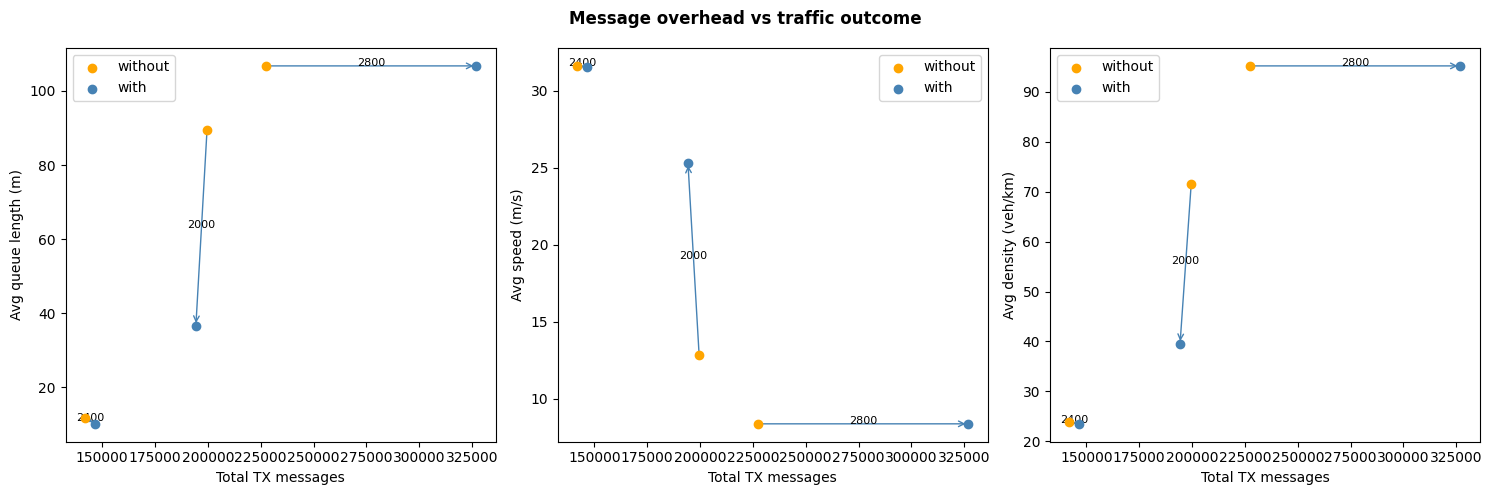

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Message overhead vs traffic outcome", fontweight="bold")

traffic_metrics = [
    ("Avg queue (m)",      "Avg queue length (m)",  False),  # lower is better
    ("Avg speed (m/s)",    "Avg speed (m/s)",        True),   # higher is better
    ("Avg density (v/km)", "Avg density (veh/km)",   False),
]

for ax, (metric, ylabel, higher_better) in zip(axes, traffic_metrics):
    for n_cars in VEH_SCENARIOS:
        wo = combined[(combined["Scenario"] == n_cars) & (combined["Condition"] == "without")].iloc[0]
        wi = combined[(combined["Scenario"] == n_cars) & (combined["Condition"] == "with")].iloc[0]

        ax.annotate("", xy=(wi["Total TX msgs"], wi[metric]),
                    xytext=(wo["Total TX msgs"], wo[metric]),
                    arrowprops=dict(arrowstyle="->", color="steelblue"))
        ax.scatter([wo["Total TX msgs"]], [wo[metric]], color="orange", zorder=5, label="without" if n_cars == 2000 else "")
        ax.scatter([wi["Total TX msgs"]], [wi[metric]], color="steelblue", zorder=5, label="with" if n_cars == 2000 else "")
        ax.annotate(f"{n_cars}", xy=((wo["Total TX msgs"] + wi["Total TX msgs"]) / 2, (wo[metric] + wi[metric]) / 2),
                    fontsize=8, ha="center")

    ax.set_xlabel("Total TX messages")
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()